# Z-score Gene Heatmap

Heatmap of ligand conditions x z-score gene expression.


# Import

In [4]:
# Repo-relative paths: inputs from imports_stable/, outputs to analysis_outs/
import os
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/02_combinatorial_screen_signalseq_SIG13"

import scanpy as sc
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False

In [3]:
## input files
adata = sc.read_h5ad(f"{IMPORTS_DIR}/SIG13/scanpy_outs/SIG13_doublets_DSB7_zscore_degs0.05cutoff.h5ad")

## these anndata object contain z-scored expression values in .X and have already been subset to degs
## get mean average across ligand conditions
adata_pb = sc.get.aggregate(adata, by=['ligand_call_DSB7'], func='mean')

# Plot Heatmap

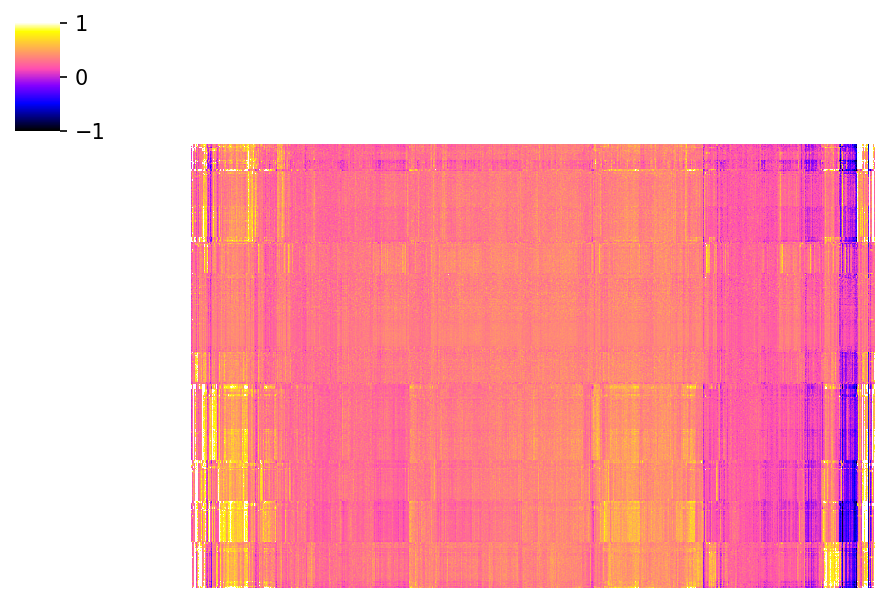

In [5]:
input_df = pd.DataFrame(adata_pb.layers['mean'].copy(), 
                       index=adata_pb.obs.index, 
                       columns=adata_pb.var.index)

cg = sns.clustermap(
    input_df,
    cmap='gnuplot2',
    vmin=-1, vmax=1,
    xticklabels=False, yticklabels=False,
    cbar=True,
    rasterized=True,
    figsize=(6, 4)
)
cg.ax_heatmap.set_xlabel('')
cg.ax_heatmap.set_ylabel('')
cg.ax_heatmap.tick_params(left=False, bottom=False)
cg.ax_row_dendrogram.set_visible(False)
cg.ax_col_dendrogram.set_visible(False)
plt.show()


In [6]:
os.makedirs(f"{OUTS_DIR}/plots", exist_ok=True)
cg.savefig(f"{OUTS_DIR}/plots/zscore_gene_heatmap.png", bbox_inches="tight")